### Exec-Readt Visuals: Lift/Gain Chart & Business Translation
- Build lift chart demonstrate how much better a model performs compared to random selection
- Create cmulative gain chart to optimize resource allocation and demonstrate ROI
- Genraate decile analysis tables that executives can interpret without technical knowledgge
- Translate technical metrice (AUC, F1, precision, recall) into business value statements
- Degign executive-ready visualizations following the 5-second comprehension rule
- Structure 2-page executive reports with clear recommendations and supporting evidence

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Set random seed for reproducibility
np.random.seed(42)

print("✓ All libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ All libraries loaded successfully!
NumPy version: 2.3.4
Pandas version: 2.3.3


In [3]:
# Generate synthetic customer churn dataset
X, y = make_classification(
    n_samples=10000,          # 10,000 customers
    n_features=20,            # 20 behavioral features
    n_informative=15,         # 15 features actually predict churn
    n_redundant=5,            # 5 features are redundant
    n_classes=2,              # Binary: churn (1) or retain (0)
    weights=[0.95, 0.05],     # 5% churn rate
    flip_y=0.01,              # 1% label noise (realistic)
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,            # 30% test set
    stratify=y,               # Preserve 5% churn rate in both sets
    random_state=42
)


print("Dataset Generated Successfully")
print("="*70)
print(f"Training set: {X_train.shape[0]:,} customers")
print(f"Test set: {X_test.shape[0]:,} customers")
print(f"\nChurn Distribution (Test Set):")
print(f"  Retained (0): {np.sum(y_test == 0):,} customers ({np.mean(y_test == 0)*100:.1f}%)")
print(f"  Churned (1): {np.sum(y_test == 1):,} customers ({np.mean(y_test == 1)*100:.1f}%)")
print("\nFeatures: 20 (usage patterns, billing, support interactions)")
print("="*70)

Dataset Generated Successfully
Training set: 7,000 customers
Test set: 3,000 customers

Churn Distribution (Test Set):
  Retained (0): 2,838 customers (94.6%)
  Churned (1): 162 customers (5.4%)

Features: 20 (usage patterns, billing, support interactions)


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(
    max_iter=1000,           # Sufficient iterations for convergence
    random_state=42,         # Reproducibility
    class_weight='balanced'  # Handle 5% imbalance
)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [5]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

accuracy = model.score(X_test_scaled, y_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Training Complete")
print("="*70)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}  (Of customers we flag, how many actually churn)")
print(f"Recall: {recall:.4f}     (Of all churners, how many do we catch)")
print(f"F1 Score: {f1:.4f}")
print("\nProbability Scores Generated:")
print(f"  Min probability: {y_proba.min():.4f}")
print(f"  Max probability: {y_proba.max():.4f}")
print(f"  Mean probability: {y_proba.mean():.4f}")
print("="*70)



Model Training Complete
Accuracy: 0.8347
Precision: 0.2101  (Of customers we flag, how many actually churn)
Recall: 0.7469     (Of all churners, how many do we catch)
F1 Score: 0.3279

Probability Scores Generated:
  Min probability: 0.0032
  Max probability: 0.9965
  Mean probability: 0.3058


In [6]:
# Show example predictions
print("\nExample Customer Scores:")
print("Customer ID | Churn Prob | Actual | Interpretation")
print("-" * 70)
for i in [0, 100, 500, 1000, 2000]:
    prob = y_proba[i]
    actual = "Churned" if y_test[i] == 1 else "Retained"
    risk = "HIGH" if prob > 0.7 else ("MEDIUM" if prob > 0.3 else "LOW")
    print(f"{i:11d} | {prob:10.4f} | {actual:7s} | {risk} risk")


Example Customer Scores:
Customer ID | Churn Prob | Actual | Interpretation
----------------------------------------------------------------------
          0 |     0.0950 | Retained | LOW risk
        100 |     0.5386 | Retained | MEDIUM risk
        500 |     0.3253 | Retained | MEDIUM risk
       1000 |     0.2892 | Retained | LOW risk
       2000 |     0.2264 | Retained | LOW risk


In [7]:
print("LIFT CALCULATION: Top 10% of Customers")
print("="*70)
sorted_indices = np.argsort(y_proba)[::-1]
y_test_sorted = y_test[sorted_indices]

top_10_percent_size = int(len(y_test) * 0.10)
top_10_percent = y_test_sorted[:top_10_percent_size]

overall_churn_rate = y_test.mean()
top_10_churn_rate = top_10_percent.mean()

print(overall_churn_rate,top_10_churn_rate)
lift_top_10 = top_10_churn_rate / overall_churn_rate



LIFT CALCULATION: Top 10% of Customers
0.054 0.36333333333333334


In [8]:
lift_top_10

np.float64(6.728395061728396)

In [9]:
print(f"\nPopulation: {len(y_test):,} customers")
print(f"Top 10% size: {top_10_percent_size:,} customers")
print(f"\nRANDOM APPROACH:")
print(f"  Expected churners in random 10%: {int(len(y_test) * 0.10 * overall_churn_rate):,}")
print(f"  Response rate: {overall_churn_rate*100:.2f}%")
print(f"\nMODEL APPROACH:")
print(f"  Actual churners in top 10%: {int(top_10_percent.sum()):,}")
print(f"  Response rate: {top_10_churn_rate*100:.2f}%")
print(f"\nLIFT:")
print(f"  {lift_top_10:.2f}× better than random")
print(f"\n💡 BUSINESS TRANSLATION:")
print(f"  'By using our model to identify the top 10% highest-risk customers,")
print(f"   we catch {lift_top_10:.1f}× more churners than calling random customers.")
print(f"   Same budget, {lift_top_10:.1f}× better results.'")
print("="*70)


Population: 3,000 customers
Top 10% size: 300 customers

RANDOM APPROACH:
  Expected churners in random 10%: 16
  Response rate: 5.40%

MODEL APPROACH:
  Actual churners in top 10%: 109
  Response rate: 36.33%

LIFT:
  6.73× better than random

💡 BUSINESS TRANSLATION:
  'By using our model to identify the top 10% highest-risk customers,
   we catch 6.7× more churners than calling random customers.
   Same budget, 6.7× better results.'


In [11]:
def calculate_cumulative_lift(y_true, y_proba, n_bins=10):
    """
    Calculate cumulative lift across population percentiles.

    Parameters:
    -----------
    y_true : array-like
        True labels (0 or 1)
    y_proba : array-like
        Predicted probabilities
    n_bins : int
        Number of bins (default 10 for deciles)

    Returns:
    --------
    percentiles : list
        Coverage percentiles (10%, 20%, ..., 100%)
    lifts : list
        Cumulative lift at each percentile
    """
    # Sort by probability (highest first)
    sorted_indices = np.argsort(y_proba)[::-1]
    y_sorted = y_true[sorted_indices]

    # Calculate overall response rate (random baseline)
    overall_rate = y_true.mean()

    percentiles = []
    lifts = []

    # Calculate lift at each decile
    for pct in range(10, 101, 10):
        cutoff = int(len(y_sorted) * pct / 100)
        segment = y_sorted[:cutoff]
        segment_rate = segment.mean()
        lift = segment_rate / overall_rate

        percentiles.append(pct)
        lifts.append(lift)

    return percentiles, lifts

# Calculate lift curve
percentiles, lifts = calculate_cumulative_lift(y_test, y_proba)

print("CUMULATIVE LIFT BY DECILE")
print("="*70)
print("Percentile | Lift   | Interpretation")
print("-" * 70)
for pct, lift in zip(percentiles, lifts):
    interpretation = "Excellent" if lift > 3 else ("Good" if lift > 2 else "Moderate")
    print(f"Top {pct:3d}%   | {lift:5.2f}× | {interpretation}")
print("="*70)

CUMULATIVE LIFT BY DECILE
Percentile | Lift   | Interpretation
----------------------------------------------------------------------
Top  10%   |  6.73× | Excellent
Top  20%   |  3.80× | Excellent
Top  30%   |  2.63× | Good
Top  40%   |  2.08× | Good
Top  50%   |  1.75× | Moderate
Top  60%   |  1.51× | Moderate
Top  70%   |  1.34× | Moderate
Top  80%   |  1.20× | Moderate
Top  90%   |  1.11× | Moderate
Top 100%   |  1.00× | Moderate


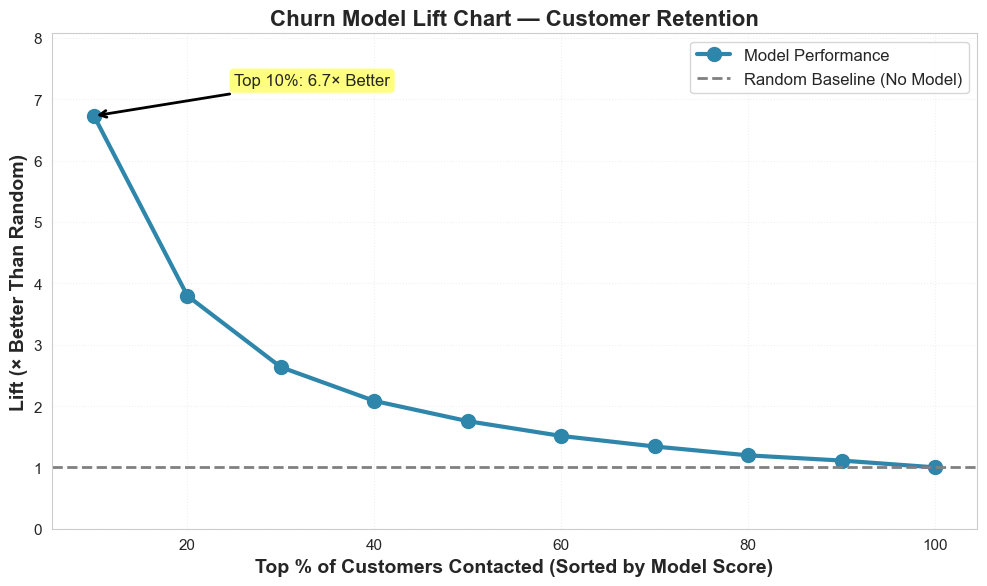


💡 EXECUTIVE SUMMARY FOR THIS CHART:
  'Our churn prediction model identifies high-risk customers 6.7× better
   than random selection. By focusing retention calls on the top 10%,
   we reach 6.7× more churners with the same budget.'


In [12]:
# Create executive-ready lift chart
plt.figure(figsize=(10, 6))

# Plot lift curve
plt.plot(percentiles, lifts,
         marker='o', linewidth=3, markersize=10,
         color='#2E86AB', label='Model Performance')

# Add random baseline
plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=2,
            label='Random Baseline (No Model)')

# Annotate key point (top decile)
top_decile_lift = lifts[0]
plt.annotate(
    f'Top 10%: {top_decile_lift:.1f}× Better',
    xy=(10, top_decile_lift),
    xytext=(25, top_decile_lift + 0.5),
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
    arrowprops=dict(arrowstyle='->', lw=2, color='black')
)

# Formatting
plt.xlabel('Top % of Customers Contacted (Sorted by Model Score)', fontsize=14, fontweight='bold')
plt.ylabel('Lift (× Better Than Random)', fontsize=14, fontweight='bold')
plt.title('Churn Model Lift Chart — Customer Retention', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3, linestyle=':')
plt.ylim(0, max(lifts) * 1.2)

plt.tight_layout()
plt.show()

print("\n💡 EXECUTIVE SUMMARY FOR THIS CHART:")
print(f"  'Our churn prediction model identifies high-risk customers {top_decile_lift:.1f}× better")
print(f"   than random selection. By focusing retention calls on the top 10%,")
print(f"   we reach {top_decile_lift:.1f}× more churners with the same budget.'")

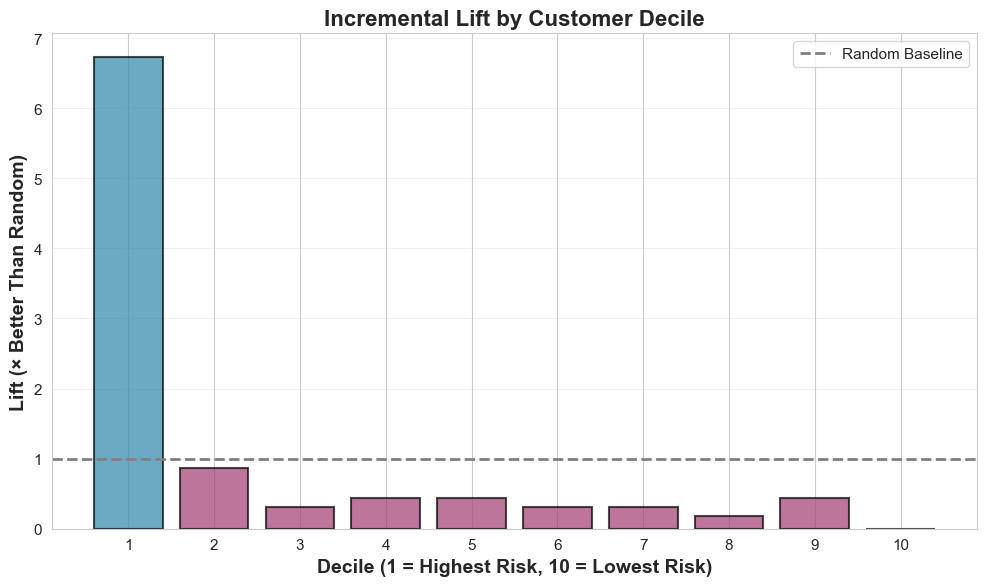


💡 KEY INSIGHT:
  Deciles 1-3 have strong lift (6.7×, 0.9×, 0.3×)
  Deciles 8-10 have weak/negative lift — don't waste resources here
  Sweet spot: Focus on top 30% for best ROI


In [13]:
def calculate_decile_lift(y_true, y_proba, n_bins=10):
    """
    Calculate lift for each individual decile (not cumulative).
    """
    sorted_indices = np.argsort(y_proba)[::-1]
    y_sorted = y_true[sorted_indices]
    overall_rate = y_true.mean()

    decile_size = len(y_sorted) // n_bins
    deciles = []
    lifts = []

    for i in range(n_bins):
        start = i * decile_size
        end = start + decile_size if i < n_bins - 1 else len(y_sorted)
        decile = y_sorted[start:end]
        decile_rate = decile.mean()
        lift = decile_rate / overall_rate

        deciles.append(i + 1)
        lifts.append(lift)

    return deciles, lifts

# Calculate incremental lift by decile
deciles, decile_lifts = calculate_decile_lift(y_test, y_proba)

# Visualize
plt.figure(figsize=(10, 6))
colors = ['#2E86AB' if lift > 1 else '#A23B72' for lift in decile_lifts]
bars = plt.bar(deciles, decile_lifts, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=2, label='Random Baseline')
plt.xlabel('Decile (1 = Highest Risk, 10 = Lowest Risk)', fontsize=14, fontweight='bold')
plt.ylabel('Lift (× Better Than Random)', fontsize=14, fontweight='bold')
plt.title('Incremental Lift by Customer Decile', fontsize=16, fontweight='bold')
plt.xticks(deciles)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT:")
print(f"  Deciles 1-3 have strong lift ({decile_lifts[0]:.1f}×, {decile_lifts[1]:.1f}×, {decile_lifts[2]:.1f}×)")
print(f"  Deciles 8-10 have weak/negative lift — don't waste resources here")
print(f"  Sweet spot: Focus on top 30% for best ROI")

In [14]:
def calculate_cumulative_gain(y_true, y_proba, n_points=100):
    """
    Calculate cumulative gain curve.

    Returns:
    --------
    percentiles : array
        Population coverage (0% to 100%)
    gains : array
        % of total positives captured at each percentile
    """
    # Sort by probability (highest first)
    sorted_indices = np.argsort(y_proba)[::-1]
    y_sorted = y_true[sorted_indices]

    total_positives = np.sum(y_true)
    n_samples = len(y_true)

    percentiles = np.linspace(0, 100, n_points)
    gains = []

    for pct in percentiles:
        n_to_check = int(n_samples * pct / 100)
        if n_to_check == 0:
            gains.append(0)
        else:
            captured = np.sum(y_sorted[:n_to_check])
            gain = (captured / total_positives) * 100
            gains.append(gain)

    return percentiles, np.array(gains)

# Calculate gain curve
percentiles_gain, gains = calculate_cumulative_gain(y_test, y_proba)

# Find key points
gain_at_10 = gains[int(0.10 * len(gains))]
gain_at_20 = gains[int(0.20 * len(gains))]
gain_at_30 = gains[int(0.30 * len(gains))]

print("CUMULATIVE GAIN ANALYSIS")
print("="*70)
print(f"At 10% coverage: {gain_at_10:.1f}% of churners captured")
print(f"At 20% coverage: {gain_at_20:.1f}% of churners captured")
print(f"At 30% coverage: {gain_at_30:.1f}% of churners captured")
print(f"\n💡 KEY FINDING:")
print(f"  Contacting top 20% captures {gain_at_20:.0f}% of all churners")
print(f"  This is {gain_at_20/20:.1f}× better than random (which would capture 20%)")
print("="*70)

CUMULATIVE GAIN ANALYSIS
At 10% coverage: 67.3% of churners captured
At 20% coverage: 75.9% of churners captured
At 30% coverage: 79.0% of churners captured

💡 KEY FINDING:
  Contacting top 20% captures 76% of all churners
  This is 3.8× better than random (which would capture 20%)


In [15]:
def calculate_cumulative_gain(y_true, y_proba, n_points=100):
    """
    Calculate cumulative gain curve.

    Returns:
    --------
    percentiles : array
        Population coverage (0% to 100%)
    gains : array
        % of total positives captured at each percentile
    """
    # Sort by probability (highest first)
    sorted_indices = np.argsort(y_proba)[::-1]
    y_sorted = y_true[sorted_indices]

    total_positives = np.sum(y_true)
    n_samples = len(y_true)

    percentiles = np.linspace(0, 100, n_points)
    gains = []

    for pct in percentiles:
        n_to_check = int(n_samples * pct / 100)
        if n_to_check == 0:
            gains.append(0)
        else:
            captured = np.sum(y_sorted[:n_to_check])
            gain = (captured / total_positives) * 100
            gains.append(gain)

    return percentiles, np.array(gains)

# Calculate gain curve
percentiles_gain, gains = calculate_cumulative_gain(y_test, y_proba)

# Find key points
gain_at_10 = gains[int(0.10 * len(gains))]
gain_at_20 = gains[int(0.20 * len(gains))]
gain_at_30 = gains[int(0.30 * len(gains))]

print("CUMULATIVE GAIN ANALYSIS")
print("="*70)
print(f"At 10% coverage: {gain_at_10:.1f}% of churners captured")
print(f"At 20% coverage: {gain_at_20:.1f}% of churners captured")
print(f"At 30% coverage: {gain_at_30:.1f}% of churners captured")
print(f"\n💡 KEY FINDING:")
print(f"  Contacting top 20% captures {gain_at_20:.0f}% of all churners")
print(f"  This is {gain_at_20/20:.1f}× better than random (which would capture 20%)")
print("="*70)

CUMULATIVE GAIN ANALYSIS
At 10% coverage: 67.3% of churners captured
At 20% coverage: 75.9% of churners captured
At 30% coverage: 79.0% of churners captured

💡 KEY FINDING:
  Contacting top 20% captures 76% of all churners
  This is 3.8× better than random (which would capture 20%)


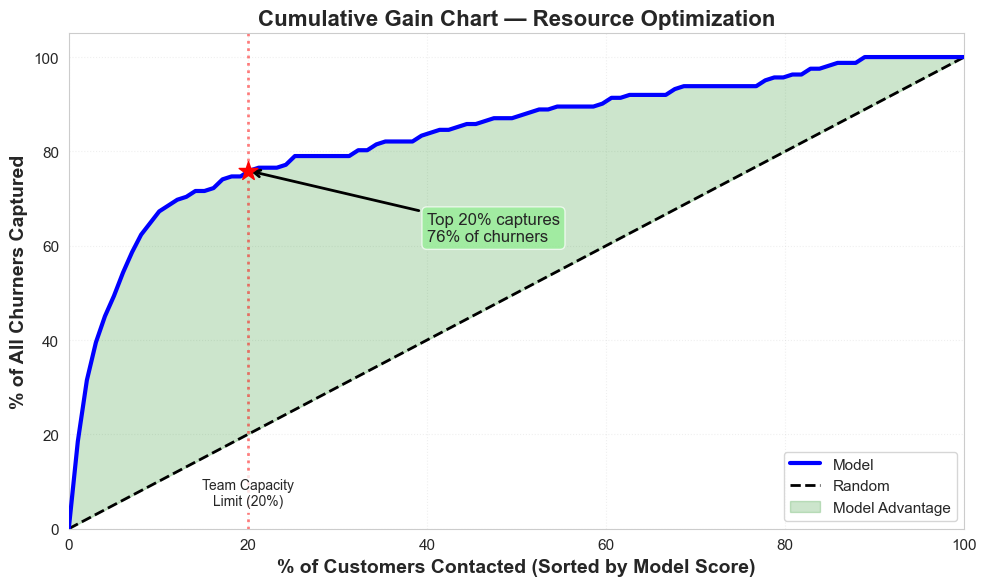


💡 EXECUTIVE SUMMARY FOR THIS CHART:
  'With our retention team's 20% capacity constraint, we can prevent
   76% of all churn by focusing on model-identified high-risk customers.
   This is 3.8× more effective than calling random customers.'

  Revenue Impact: 123 churners saved ×  500 =  61,500
  vs. Random: 32 churners saved ×  500 =  16,200
  Additional Value:  45,299 per month


In [16]:
# Create executive-ready cumulative gain chart
plt.figure(figsize=(10, 6))

# Plot model curve
plt.plot(percentiles_gain, gains, linewidth=3, color='blue', label='Model', zorder=3)

# Plot random baseline (diagonal)
plt.plot([0, 100], [0, 100], 'k--', linewidth=2, label='Random', zorder=2)

# Fill area between curves (visual emphasis)
plt.fill_between(percentiles_gain, gains, percentiles_gain,
                 where=(gains >= percentiles_gain),
                 alpha=0.2, color='green', label='Model Advantage')

# Annotate 20% point (business constraint)
plt.scatter([20], [gain_at_20], s=200, color='red', zorder=4, marker='*')
plt.annotate(
    f'Top 20% captures\n{gain_at_20:.0f}% of churners',
    xy=(20, gain_at_20),
    xytext=(40, gain_at_20 - 15),
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
    arrowprops=dict(arrowstyle='->', lw=2, color='black')
)

# Add vertical line at capacity constraint
plt.axvline(x=20, color='red', linestyle=':', linewidth=2, alpha=0.5)
plt.text(20, 5, 'Team Capacity\nLimit (20%)', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Formatting
plt.xlabel('% of Customers Contacted (Sorted by Model Score)', fontsize=14, fontweight='bold')
plt.ylabel('% of All Churners Captured', fontsize=14, fontweight='bold')
plt.title('Cumulative Gain Chart — Resource Optimization', fontsize=16, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3, linestyle=':')
plt.xlim(0, 100)
plt.ylim(0, 105)

plt.tight_layout()
plt.show()

print("\n💡 EXECUTIVE SUMMARY FOR THIS CHART:")
print(f"  'With our retention team's 20% capacity constraint, we can prevent")
print(f"   {gain_at_20:.0f}% of all churn by focusing on model-identified high-risk customers.")
print(f"   This is {gain_at_20/20:.1f}× more effective than calling random customers.'")
print(f"\n  Revenue Impact: {int(y_test.sum() * gain_at_20/100)} churners saved ×  500 =  {int(y_test.sum() * gain_at_20/100 * 500):,}")
print(f"  vs. Random: {int(y_test.sum() * 0.20)} churners saved ×  500 =  {int(y_test.sum() * 0.20 * 500):,}")
print(f"  Additional Value:  {int(y_test.sum() * (gain_at_20/100 - 0.20) * 500):,} per month")